# Training & Evaluation

Train both BiLSTM and Transformer models using optimized hyperparameters from `01_optimization.ipynb`.

In [1]:
import sys; sys.path.insert(0, '..')
from src import suppress_logs; suppress_logs()

import torch
torch.set_float32_matmul_precision('medium')

import json
from pathlib import Path
from pytorch_lightning import seed_everything
from src.data import GestureDataModule
from src.models import BiLSTMModule, TransformerModule
from src.training import CrossValidator
from src.visualization import plot_cv_comparison, print_results_table

/home/marcantoniolopez/Documenti/github/dylem-grid/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
EPOCHS = 50
PATIENCE = 15
N_FOLDS = 5
SEED = 42
DATA_PATH = None  # Auto-download from HuggingFace

seed_everything(SEED)
print(f'Training: {EPOCHS} epochs, {N_FOLDS}-fold CV')

Seed set to 42


Training: 50 epochs, 5-fold CV


## Load Optimized Hyperparameters

Loads best parameters from `01_optimization.ipynb` output. Falls back to defaults if not found.

In [3]:
OPTUNA_DIR = Path('../results/optuna')

# Default hyperparameters (fallback)
DEFAULT_PARAMS = {
    'bilstm': {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.15, 'learning_rate': 0.002, 'optimizer': 'nadam'},
    'transformer': {'d_model': 64, 'nhead': 8, 'num_layers': 2, 'dim_feedforward': 128, 'dropout': 0.1, 'learning_rate': 0.001}
}

def load_best_params(model_name):
    """Load best params from JSON or use defaults."""
    json_path = OPTUNA_DIR / f'{model_name}_best_params.json'
    if json_path.exists():
        with open(json_path) as f:
            data = json.load(f)
            print(f'{model_name.upper()}: Loaded from {json_path} (acc={data["best_accuracy"]:.4f})')
            return data['params']
    else:
        print(f'{model_name.upper()}: Using defaults (run in 01_optimization.ipynb first)')
        return DEFAULT_PARAMS[model_name]

BILSTM_PARAMS = load_best_params('bilstm')
TRANSFORMER_PARAMS = load_best_params('transformer')

print('\nBiLSTM params:', BILSTM_PARAMS)
print('Transformer params:', TRANSFORMER_PARAMS)

BILSTM: Loaded from ../results/optuna/bilstm_best_params.json (acc=0.9725)
TRANSFORMER: Loaded from ../results/optuna/transformer_best_params.json (acc=0.9650)

BiLSTM params: {'hidden_size': 128, 'num_layers': 2, 'learning_rate': 0.00034729242536492283, 'dropout': 0.26201727803516167, 'weight_decay': 6.571283758934225e-05, 'optimizer': 'adam'}
Transformer params: {'d_model': 128, 'nhead': 8, 'num_layers': 2, 'dim_feedforward': 256, 'learning_rate': 0.0025862961503026792, 'dropout': 0.13711470869610684, 'weight_decay': 2.3994178960564176e-05, 'optimizer': 'adamw'}


## Load Data

In [4]:
dm = GestureDataModule(data_path=DATA_PATH, seed=SEED)
dm.setup()
print(f'Classes: {dm.class_names}')
print(f'Input size: {dm.input_size}, Samples: {len(dm.train_dataset) + len(dm.val_dataset)}')

Classes: [np.str_('air_quotes'), np.str_('finger_wagging'), np.str_('waving'), np.str_('zoom')]
Input size: 24, Samples: 400


## Train Both Models

In [5]:
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

CHECKPOINT_DIR = Path('../models/checkpoints')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

results = {}

def train_with_cv_and_save(model_class, params, name):
    """Cross-validate model and save final checkpoint."""
    print(f'\n{"="*60}\nTraining {name.upper()}\n{"="*60}')
    
    # 1. Cross-validation for robust metrics
    cv = CrossValidator(model_class, dm, N_FOLDS, {'max_epochs': EPOCHS, 'accelerator': 'auto'})
    cv_results = cv.run(params, patience=PATIENCE)
    
    # 2. Final training on full train set + save checkpoint
    print(f'\nTraining final {name} model for checkpoint...')
    dm.cv_fold = None  # Reset to use full train/val split
    dm.setup()
    
    model = model_class(input_size=dm.input_size, num_classes=dm.num_classes, **params)
    
    checkpoint_cb = ModelCheckpoint(
        dirpath=CHECKPOINT_DIR,
        filename=f'{name}_best',
        monitor='val_acc',
        mode='max',
        save_top_k=1
    )
    early_cb = EarlyStopping(monitor='val_acc', mode='max', patience=PATIENCE, verbose=False)
    
    trainer = Trainer(
        max_epochs=EPOCHS,
        callbacks=[checkpoint_cb, early_cb],
        accelerator='auto',
        enable_progress_bar=True,
        enable_model_summary=False,
        logger=False
    )
    trainer.fit(model, dm)
    print(f'✓ Saved checkpoint: {checkpoint_cb.best_model_path}')
    
    return cv_results

# Train both models
results['bilstm'] = train_with_cv_and_save(BiLSTMModule, BILSTM_PARAMS, 'bilstm')
results['transformer'] = train_with_cv_and_save(TransformerModule, TRANSFORMER_PARAMS, 'transformer')



Training BILSTM

5-Fold Cross-Validation

--- Fold 1/5 ---
Acc: 0.9875, F1: 0.9875

--- Fold 2/5 ---
Acc: 0.9750, F1: 0.9750

--- Fold 3/5 ---
Acc: 0.9625, F1: 0.9630

--- Fold 4/5 ---
Acc: 0.9750, F1: 0.9750

--- Fold 5/5 ---
Acc: 0.9625, F1: 0.9625

CROSS-VALIDATION: 5 folds
Accuracy: 0.9725 ± 0.0094
F1 Score: 0.9726 ± 0.0093
  Fold 1: Acc=0.9875
  Fold 2: Acc=0.9750
  Fold 3: Acc=0.9625
  Fold 4: Acc=0.9750
  Fold 5: Acc=0.9625

Training final bilstm model for checkpoint...


✓ Saved checkpoint: /home/marcantoniolopez/Documenti/github/dylem-grid/models/checkpoints/bilstm_best-v2.ckpt

Training TRANSFORMER

5-Fold Cross-Validation

--- Fold 1/5 ---
Acc: 0.9375, F1: 0.9371

--- Fold 2/5 ---
Acc: 0.9625, F1: 0.9624

--- Fold 3/5 ---
Acc: 0.9375, F1: 0.9395

--- Fold 4/5 ---
Acc: 0.9500, F1: 0.9495

--- Fold 5/5 ---
Acc: 0.9500, F1: 0.9506

CROSS-VALIDATION: 5 folds
Accuracy: 0.9475 ± 0.0094
F1 Score: 0.9478 ± 0.0090
  Fold 1: Acc=0.9375
  Fold 2: Acc=0.9625
  Fold 3: Acc=0.9375
  Fold 4: Acc=0.9500
  Fold 5: Acc=0.9500

Training final transformer model for checkpoint...


✓ Saved checkpoint: /home/marcantoniolopez/Documenti/github/dylem-grid/models/checkpoints/transformer_best-v1.ckpt


## Results Comparison

In [6]:
print_results_table(results)


RESULTS SUMMARY
Model           Accuracy        F1              Epochs
------------------------------------------------------------
BILSTM          0.9725 ± 0.0094  0.9726 ± 0.0093  5 folds
TRANSFORMER     0.9475 ± 0.0094  0.9478 ± 0.0090  5 folds


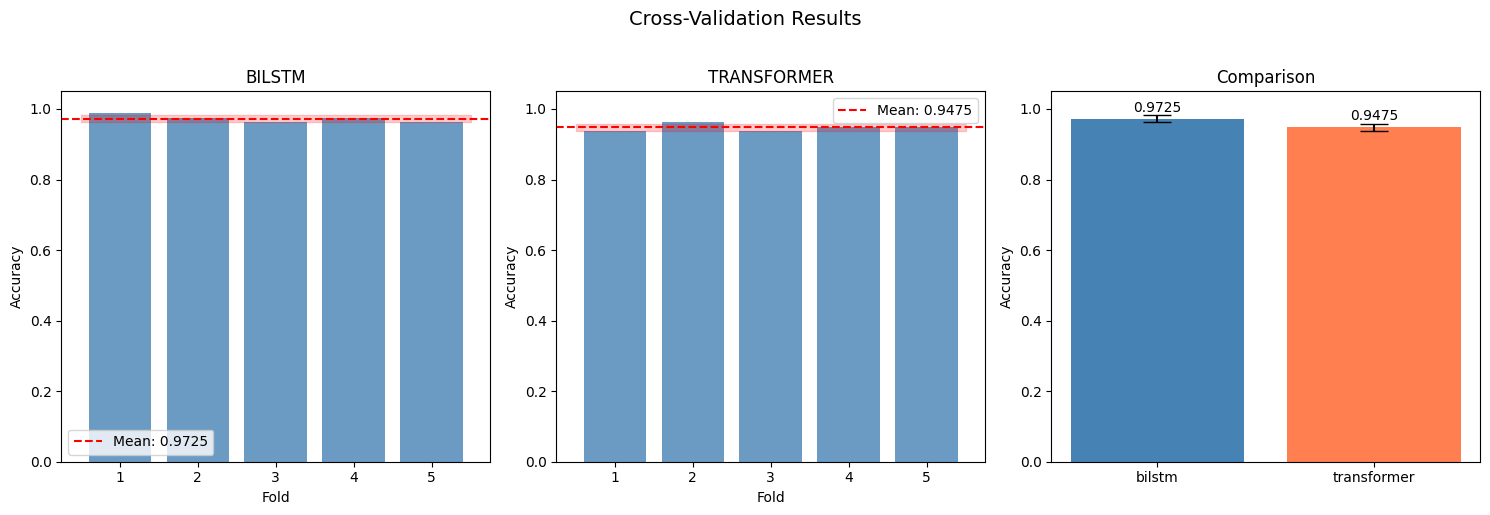

In [7]:
fig = plot_cv_comparison(results, 'Cross-Validation Results')
Path('../plots').mkdir(exist_ok=True)
fig.savefig('../plots/cv_comparison.png', dpi=150)

## Save Results

In [8]:
Path('../results/training').mkdir(parents=True, exist_ok=True)
for name, r in results.items():
    with open(f'../results/training/{name}_cv_results.json', 'w') as f:
        json.dump(r.to_dict(), f, indent=2)
print('Results saved to ../results/training/')

Results saved to ../results/training/
